In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # importing 5 more things from sklearn

In [36]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()

data=pd.DataFrame(housing.data)
#converting into pandas dataframe

In [38]:
data.columns=housing.feature_names
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [40]:
data['PRICE']=housing.target

In [42]:
data.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

In [44]:
x=data.drop(['PRICE'],axis=1)  #axis=1 for column
y=data['PRICE']

#data.drop(range(0, 100), axis=0)  for rows

In [50]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=0)  

#  random_state = split is reproducible — you get the same training and testing data each time you run the code

In [52]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression()

In [54]:
model=lm.fit(xtrain,ytrain)  #"Fitting" means the model learns the relationship between

#xtrain: Features (independent variables) of the training set.
#ytrain: Target (dependent variable) of the training set.

In [56]:
ytrain_pred=lm.predict(xtrain)  #predicted target values for the test set (xtest)
ytest_pred=lm.predict(xtest)

In [60]:
#df=pd.DataFrame(ytrain_pred,ytrain)
#df=pd.DataFrame(ytest_pred,ytest)

df_train = pd.DataFrame({'Actual': ytrain, 'Predicted': ytrain_pred})
df_test = pd.DataFrame({'Actual': ytest, 'Predicted': ytest_pred})


In [62]:
from sklearn.metrics import mean_squared_error, r2_score

In [66]:
mse=mean_squared_error(ytest,ytest_pred)
print(mse)
# Lower MSE indicates better model performance.
#represents the average squared error between the actual and predicted values 

0.5289841670367224


In [68]:
mse=mean_squared_error(ytrain_pred,ytrain)
print(mse)

0.5234413607125449


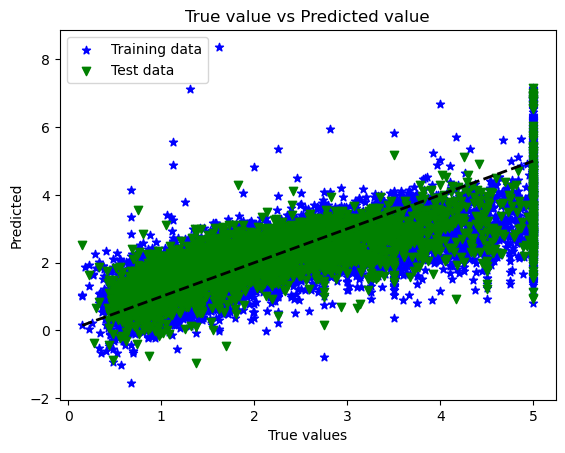

In [122]:
plt.scatter(ytrain, ytrain_pred, color='blue', marker='*', label='Training data')  # circle markers
plt.scatter(ytest, ytest_pred, color='green', marker='v', label='Test data')   # square markers
plt.xlabel('True values')
plt.ylabel('Predicted')
plt.title("True value vs Predicted value")
plt.legend(loc='upper left')

# Draw a perfect prediction line (45-degree dashed line) from min -> max
min_val = min(ytrain.min(), ytest.min())
max_val = max(ytrain.max(), ytest.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)  # 'k--' means black dashed line
                                                               #'k' stands for black color (k = black in matplotlib's short color codes).
                                                               #'--' makes the line dashed. 
                                                                # lw = linewidth
#twice minmax Value cuz — once for x-axis and once for y-axis — to draw a diagonal line 

plt.show()


The scatter plot of true values versus predicted values shows that the majority of the points are close to the ideal 45-degree line, indicating that the model’s predictions are generally accurate. However, towards the higher true values, some points show a slight deviation below the line, suggesting that the model may slightly underpredict the target values for those instances. Despite this minor deviation, the overall performance of the model is strong, and it appears to generalize well across both the training and testing data without significant overfitting.

Represents the line where predicted = actual (ideal prediction).

A good model will have points close to the dashed line.